In [1]:
import pymc as pm
import numpy as np
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
# import matplotlib
# matplotlib.use('tkagg')

### 0. Data cleaning
Please ignore data cleaning steps below as cleaned data is provided as well.

In [2]:
df_raw = pd.read_csv("seoul19072025.csv", skiprows=11, encoding="cp949")
df_raw.head(3)

,\t\t지점번호,지점명,일시,평균기온(℃),평균최고기온(℃),최고기온(℃),\t최고기온일자,평균최저기온(℃),최저기온(℃),최저기온일자
0,108,서울,1907-10,13.9,20.2,25.4,1907-10-05,8.3,3.3,1907-10-24
1,108,서울,1907-11,5.3,10.2,21.3,1907-11-01,0.6,-8.9,1907-11-30
2,108,서울,1907-12,-3.9,0.8,9.0,1907-12-13,-8.7,-20.1,1907-12-23


In [3]:
# translate and rename columns
df_raw.columns = [
    "station_id",
    "location",
    "year_month",
    "avg_temp",
    "avg_max_temp",
    "max_temp",
    "date_of_max_temp",
    "avg_min_temp",
    "min_temp",
    "date_of_min_temp"
]
#df.head(3)
# save cleaned df
df_raw.to_csv("6720_seoul_19072024.csv", index=False)

In [4]:
# load cleaned df
df_raw = pd.read_csv("6720_seoul_19072024.csv")
df_raw.head(3)

,station_id,location,year_month,avg_temp,avg_max_temp,max_temp,date_of_max_temp,avg_min_temp,min_temp,date_of_min_temp
0,108,서울,1907-10,13.9,20.2,25.4,1907-10-05,8.3,3.3,1907-10-24
1,108,서울,1907-11,5.3,10.2,21.3,1907-11-01,0.6,-8.9,1907-11-30
2,108,서울,1907-12,-3.9,0.8,9.0,1907-12-13,-8.7,-20.1,1907-12-23


In [5]:
# convert date into datetime formate
df_raw["year_month"] = pd.to_datetime(df_raw["year_month"], format="%Y-%m")
df_raw["date_of_max_temp"] = pd.to_datetime(df_raw["date_of_max_temp"])
df_raw["date_of_min_temp"] = pd.to_datetime(df_raw["date_of_min_temp"])
df_raw['month'] = df_raw['year_month'].dt.month
df_raw['year'] = df_raw['year_month'].dt.year
df_raw['t'] = np.arange(len(df_raw))
df_raw.head(3)

,station_id,location,year_month,avg_temp,avg_max_temp,max_temp,date_of_max_temp,avg_min_temp,min_temp,date_of_min_temp,month,year,t
0,108,서울,1907-10-01,13.9,20.2,25.4,1907-10-05,8.3,3.3,1907-10-24,10,1907,0
1,108,서울,1907-11-01,5.3,10.2,21.3,1907-11-01,0.6,-8.9,1907-11-30,11,1907,1
2,108,서울,1907-12-01,-3.9,0.8,9.0,1907-12-13,-8.7,-20.1,1907-12-23,12,1907,2


Some years had empty months so had to fill in.

In [6]:
df_raw["year"] = df_raw["year_month"].dt.year
df_raw["month"] = df_raw["year_month"].dt.month

month_counts = df_raw.groupby("year")["month"].nunique()
incomplete_years = month_counts[month_counts < 12]

if not incomplete_years.empty:
    print("Years with missing months:")
    print(incomplete_years)

# fill in empty months
years = df_raw["year"].unique()
months = list(range(1, 13))
full_grid = pd.MultiIndex.from_product([years, months], names=["year", "month"])
full_df = pd.DataFrame(index=full_grid).reset_index()
df_full = pd.merge(full_df, df_raw, on=["year", "month"], how="left")

df_full["year_month"] = pd.to_datetime(dict(year=df_full["year"], month=df_full["month"], day=1))

df_full.head(10)

Years with missing months:
year
1907     3
1950    10
1951     1
1952    11
2025     3
Name: month, dtype: int64


,year,month,station_id,location,year_month,avg_temp,avg_max_temp,max_temp,date_of_max_temp,avg_min_temp,min_temp,date_of_min_temp,t
0,1907,1,NaN,NaN,1907-01-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN
1,1907,2,NaN,NaN,1907-02-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN
2,1907,3,NaN,NaN,1907-03-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN
3,1907,4,NaN,NaN,1907-04-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN
4,1907,5,NaN,NaN,1907-05-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN
5,1907,6,NaN,NaN,1907-06-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN
6,1907,7,NaN,NaN,1907-07-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN
7,1907,8,NaN,NaN,1907-08-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN
8,1907,9,NaN,NaN,1907-09-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN
9,1907,10,108.0,서울,1907-10-01,13.9,20.2,25.4,1907-10-05,8.3,3.3,1907-10-24,0.0


In [7]:
#check for empty columns
start_date = "1950-07-01"
end_date = "1951-12-31"

df_check_na = df_full[(df_full["year_month"] >= start_date) & (df_full["year_month"] <= end_date)]

df_check_na.head(5)

,year,month,station_id,location,year_month,avg_temp,avg_max_temp,max_temp,date_of_max_temp,avg_min_temp,min_temp,date_of_min_temp,t
522,1950,7,108.0,서울,1950-07-01,26.0,30.5,36.1,1950-07-27,22.6,16.5,1950-07-02,513.0
523,1950,8,108.0,서울,1950-08-01,26.5,32.7,36.9,1950-08-19,22.1,15.2,1950-08-24,514.0
524,1950,9,108.0,서울,1950-09-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,515.0
525,1950,10,108.0,서울,1950-10-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,516.0
526,1950,11,NaN,NaN,1950-11-01,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN


### 1. Modeling

In [8]:
start_date = "1908-07-01"
end_date = "2024-12-31"
df = df_full[(df_full["year_month"] >= start_date) & (df_full["year_month"] <= end_date)]

In [9]:
# mask missing years (1950–1953)
missing_years = (df['year'] >= 1950) & (df['year'] <= 1953)
mask_missing = missing_years.to_numpy()

data_observed_test = df.loc[~missing_years, 'avg_temp'].values
time_observed = df.loc[~missing_years, 't'].values
month_observed = df.loc[~missing_years, 'month'].values - 1

time_full = df['t'].values
month_full = df['month'].values - 1

# standardize observed data
mean_temp = data_observed_test.mean()
std_temp = data_observed_test.std()
observed_data_std = (data_observed_test - mean_temp) / std_temp

with pm.Model() as model:
    # priors
    sigma = pm.HalfNormal("sigma", sigma=5.0)
    sigma_trend = pm.HalfNormal("sigma_trend", sigma=2.0)
    sigma_season = pm.HalfNormal("sigma_season", sigma=2.0)
    # trend
    mu = pm.GaussianRandomWalk("mu", sigma=sigma_trend, shape=len(time_full))
    # seasonal pattern
    gamma = pm.Normal("gamma", mu=0, sigma=sigma_season, shape=12)
    gamma_centered = gamma - pm.math.mean(gamma)
    # mu
    y_hat = mu + gamma_centered[month_full]
    # likelihood
    y_obs = pm.Normal("y_obs", mu=y_hat[~mask_missing], sigma=sigma, observed=observed_data_std)

    trace = pm.sample(
        2000,
        tune=2000,
        target_accept=0.97,
        max_treedepth=20
    )

D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pymc\distributions\timeseries.py:297: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pytensor\link\c\cmodule.py:2959: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-tes

Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 879 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [10]:
summary = az.summary(trace, hdi_prob=0.95, round_to=3)
print(summary)

               mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
mu[0]        -0.124  0.039    -0.201     -0.047      0.000    0.001   
mu[1]        -0.124  0.038    -0.199     -0.049      0.000    0.001   
mu[2]        -0.123  0.036    -0.198     -0.055      0.000    0.001   
mu[3]        -0.123  0.035    -0.194     -0.057      0.000    0.001   
mu[4]        -0.124  0.034    -0.194     -0.061      0.000    0.000   
...             ...    ...       ...        ...        ...      ...   
gamma[10]    -0.516  0.331    -1.188      0.138      0.003    0.005   
gamma[11]    -1.236  0.331    -1.905     -0.578      0.003    0.005   
sigma         0.132  0.003     0.126      0.138      0.000    0.000   
sigma_trend   0.013  0.004     0.007      0.019      0.001    0.000   
sigma_season  1.136  0.274     0.684      1.677      0.004    0.005   

               ess_bulk  ess_tail  r_hat  
mu[0]         10719.421  6772.661  1.006  
mu[1]         10854.858  7033.867  1.006  
mu[2]          999

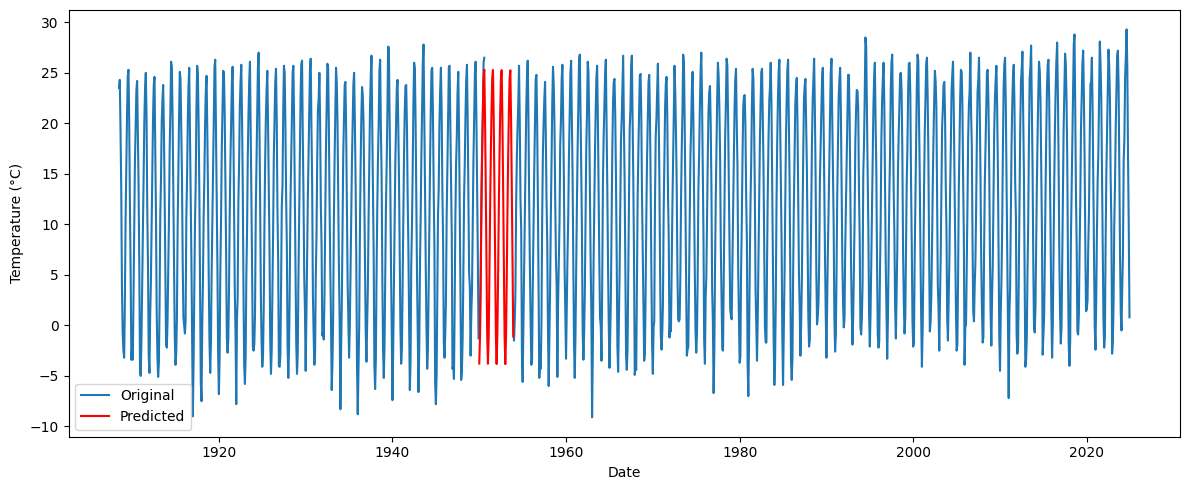

In [11]:
# extract posterior
mu_mean = trace.posterior['mu'].mean(dim=("chain", "draw")).values
gamma_mean = trace.posterior['gamma'].mean(dim=("chain", "draw")).values

# predict missing years
predicted_missing_std = mu_mean[mask_missing] + gamma_mean[month_full[mask_missing]]
predicted_missing = (predicted_missing_std * std_temp) + mean_temp

plt.figure(figsize=(12, 5))
plt.plot(df['year_month'], df['avg_temp'], label="Original")
plt.plot(df['year_month'][missing_years], predicted_missing, label="Predicted", color="red")
plt.legend()
plt.ylabel("Temperature (°C)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

### 2. Validation
Now we will validate our result with 5 other periods.

Validation windows: [[1958, 1959, 1960, 1961], [1963, 1964, 1965, 1966], [1931, 1932, 1933, 1934], [1974, 1975, 1976, 1977], [2007, 2008, 2009, 2010]]
missing years: [1958, 1959, 1960, 1961]


D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pymc\distributions\timeseries.py:297: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, sigma_trend, sigma_season, mu, gamma]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 919 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


               mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
mu[0]        -0.123  0.036    -0.197     -0.055      0.000    0.000   
mu[1]        -0.123  0.035    -0.192     -0.053      0.000    0.000   
mu[2]        -0.123  0.034    -0.189     -0.054      0.000    0.000   
mu[3]        -0.123  0.033    -0.190     -0.060      0.000    0.000   
mu[4]        -0.123  0.032    -0.186     -0.060      0.000    0.000   
...             ...    ...       ...        ...        ...      ...   
gamma[10]    -0.522  0.338    -1.211      0.136      0.003    0.006   
gamma[11]    -1.244  0.338    -1.907     -0.565      0.003    0.006   
sigma         0.133  0.003     0.127      0.138      0.000    0.000   
sigma_trend   0.011  0.003     0.006      0.016      0.000    0.000   
sigma_season  1.143  0.279     0.708      1.709      0.004    0.008   

               ess_bulk  ess_tail  r_hat  
mu[0]          9661.907  6729.904  1.001  
mu[1]         10151.004  6508.464  1.000  
mu[2]         1028

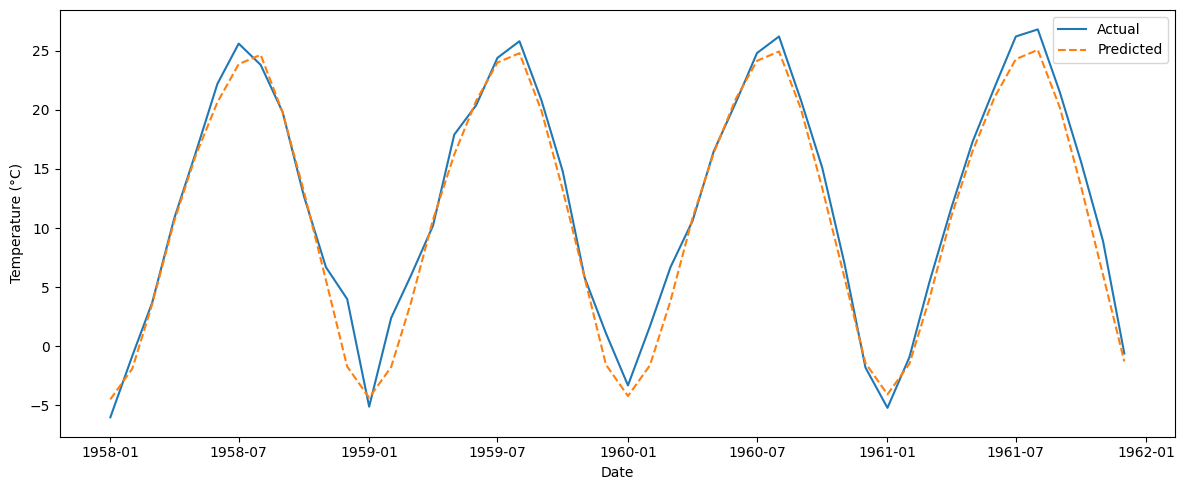

missing years: [1963, 1964, 1965, 1966]


D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pymc\distributions\timeseries.py:297: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, sigma_trend, sigma_season, mu, gamma]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 925 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


               mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
mu[0]        -0.125  0.039    -0.206     -0.051      0.000    0.000   
mu[1]        -0.124  0.038    -0.200     -0.053      0.000    0.000   
mu[2]        -0.124  0.036    -0.193     -0.053      0.000    0.000   
mu[3]        -0.124  0.035    -0.191     -0.056      0.000    0.000   
mu[4]        -0.124  0.033    -0.190     -0.058      0.000    0.000   
...             ...    ...       ...        ...        ...      ...   
gamma[10]    -0.517  0.344    -1.246      0.123      0.003    0.005   
gamma[11]    -1.236  0.344    -1.940     -0.580      0.003    0.005   
sigma         0.132  0.003     0.126      0.139      0.001    0.000   
sigma_trend   0.013  0.003     0.007      0.020      0.001    0.000   
sigma_season  1.144  0.271     0.705      1.697      0.004    0.005   

               ess_bulk  ess_tail  r_hat  
mu[0]         11843.621  7134.375  1.007  
mu[1]         12216.291  6174.930  1.005  
mu[2]         1224

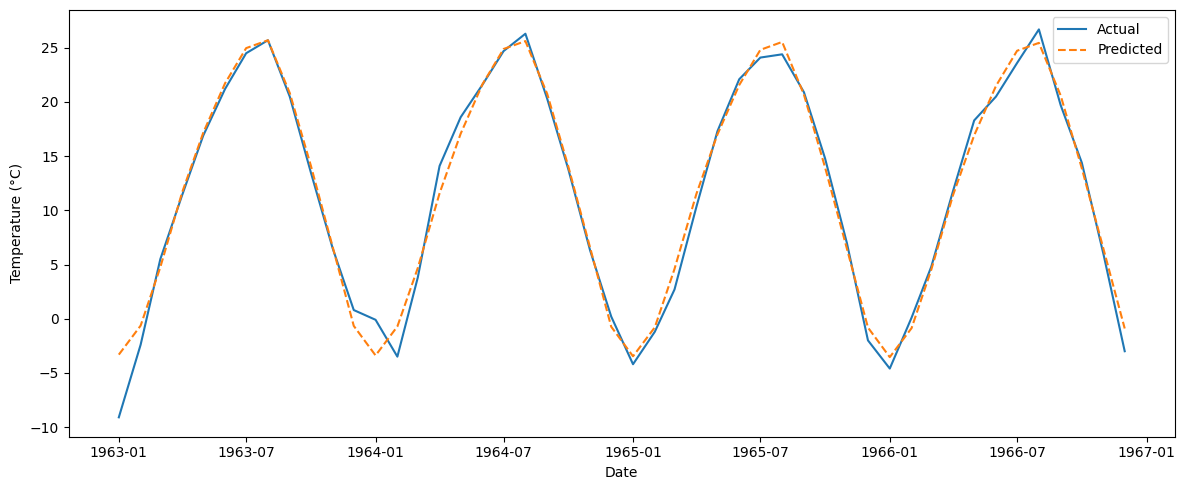

missing years: [1931, 1932, 1933, 1934]


D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pymc\distributions\timeseries.py:297: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, sigma_trend, sigma_season, mu, gamma]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 936 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


               mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
mu[0]        -0.127  0.037    -0.201     -0.053      0.000    0.001   
mu[1]        -0.127  0.036    -0.197     -0.056      0.000    0.001   
mu[2]        -0.127  0.034    -0.197     -0.063      0.000    0.000   
mu[3]        -0.127  0.033    -0.194     -0.064      0.000    0.000   
mu[4]        -0.127  0.032    -0.192     -0.065      0.000    0.000   
...             ...    ...       ...        ...        ...      ...   
gamma[10]    -0.517  0.346    -1.191      0.184      0.003    0.005   
gamma[11]    -1.243  0.346    -1.938     -0.563      0.003    0.005   
sigma         0.133  0.003     0.126      0.138      0.001    0.000   
sigma_trend   0.011  0.003     0.005      0.017      0.001    0.000   
sigma_season  1.145  0.275     0.685      1.689      0.004    0.005   

               ess_bulk  ess_tail  r_hat  
mu[0]         10599.061  7319.654  1.005  
mu[1]         10852.167  5973.929  1.004  
mu[2]         1064

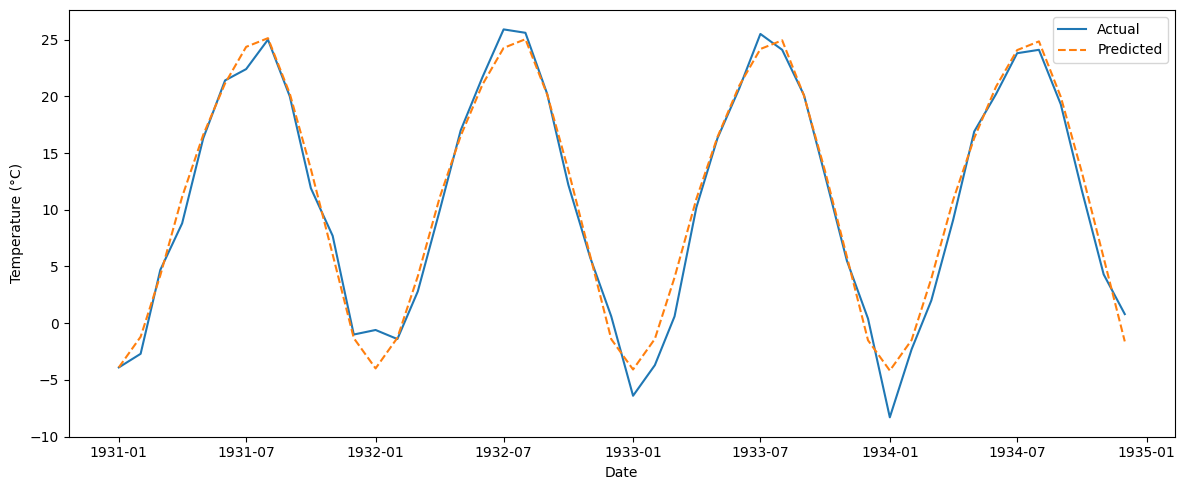

missing years: [1974, 1975, 1976, 1977]


D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pymc\distributions\timeseries.py:297: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, sigma_trend, sigma_season, mu, gamma]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 877 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


               mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
mu[0]        -0.124  0.036    -0.194     -0.054      0.000    0.001   
mu[1]        -0.124  0.035    -0.189     -0.054      0.000    0.000   
mu[2]        -0.124  0.033    -0.191     -0.059      0.000    0.000   
mu[3]        -0.123  0.032    -0.186     -0.058      0.000    0.000   
mu[4]        -0.124  0.031    -0.188     -0.065      0.000    0.000   
...             ...    ...       ...        ...        ...      ...   
gamma[10]    -0.517  0.351    -1.233      0.165      0.003    0.005   
gamma[11]    -1.241  0.351    -1.969     -0.574      0.003    0.005   
sigma         0.133  0.003     0.127      0.139      0.000    0.000   
sigma_trend   0.010  0.003     0.005      0.016      0.001    0.000   
sigma_season  1.144  0.275     0.724      1.709      0.003    0.005   

               ess_bulk  ess_tail  r_hat  
mu[0]         11895.797  6246.693  1.002  
mu[1]         12231.613  6736.364  1.002  
mu[2]         1262

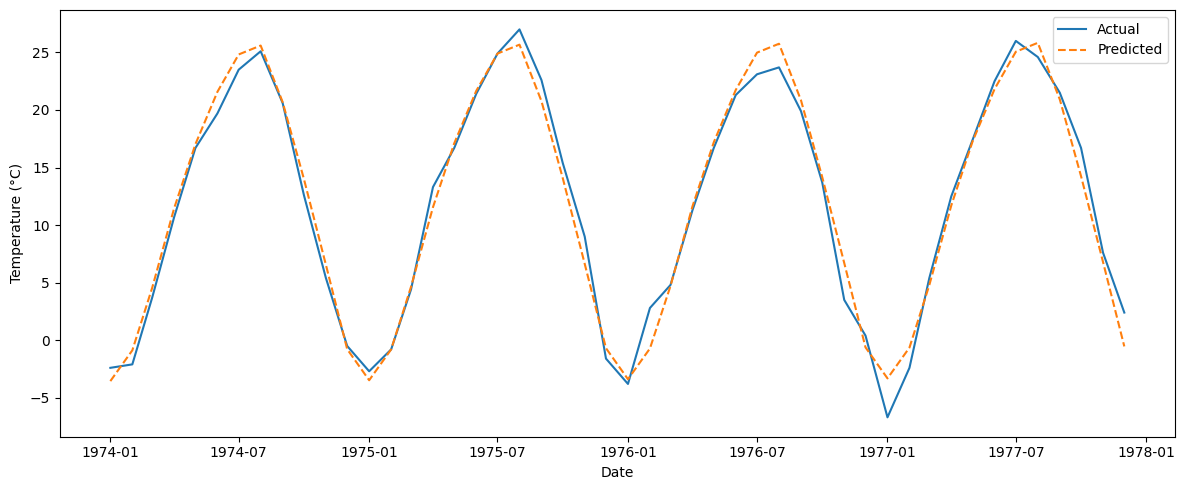

missing years: [2007, 2008, 2009, 2010]


D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pymc\distributions\timeseries.py:297: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, sigma_trend, sigma_season, mu, gamma]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 955 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


               mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
mu[0]        -0.121  0.035    -0.194     -0.054      0.000    0.001   
mu[1]        -0.121  0.034    -0.188     -0.055      0.000    0.001   
mu[2]        -0.121  0.033    -0.187     -0.057      0.000    0.001   
mu[3]        -0.121  0.032    -0.185     -0.060      0.000    0.001   
mu[4]        -0.121  0.031    -0.182     -0.061      0.000    0.001   
...             ...    ...       ...        ...        ...      ...   
gamma[10]    -0.519  0.341    -1.191      0.175      0.003    0.005   
gamma[11]    -1.239  0.341    -1.918     -0.556      0.003    0.005   
sigma         0.134  0.003     0.128      0.140      0.001    0.000   
sigma_trend   0.010  0.003     0.004      0.016      0.001    0.000   
sigma_season  1.143  0.273     0.689      1.675      0.004    0.006   

               ess_bulk  ess_tail  r_hat  
mu[0]         10004.015  3824.566  1.013  
mu[1]          9885.843  3553.152  1.013  
mu[2]          964

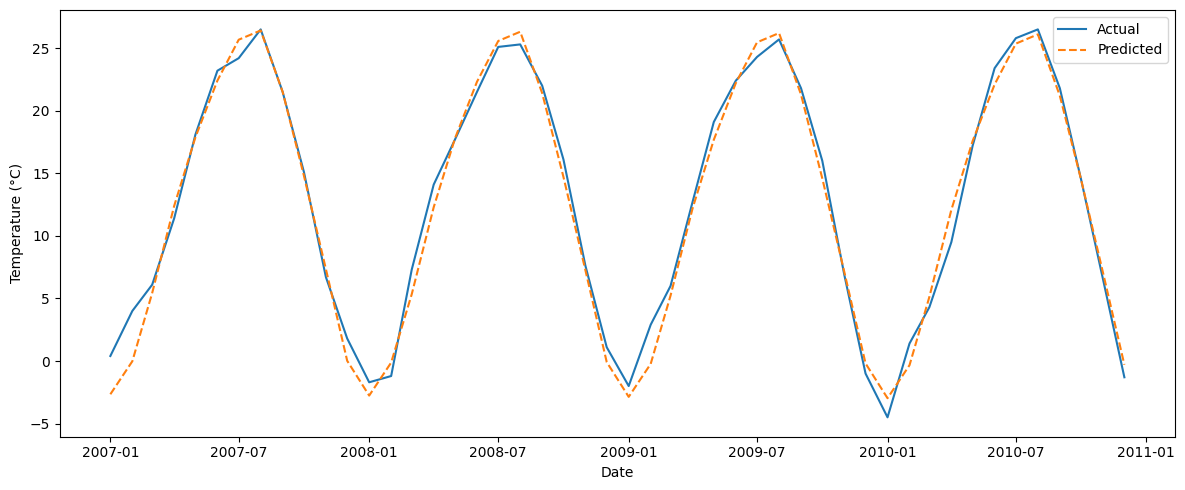

In [14]:
# Define valid test windows
years = sorted(df['year'].unique())
valid_years = [y for y in years if y not in range(1950, 1954) and y <= 2020]
np.random.seed(6720)
samples = []

while len(samples) < 5:
    y = np.random.choice(valid_years)
    window = list(range(y, y + 4))
    if all(w in valid_years for w in window) and not any(set(window).intersection(set(sum(samples, [])))):
        samples.append(window)

print("Validation windows:", samples)

result = []

for idx, window in enumerate(samples):
    print("missing years:", window)

    mask_test = df['year'].isin(window)
    mask_test_np = mask_test.to_numpy()
    mask_train = ~mask_test & ~df['year'].between(1950, 1953)
    mask_train_np = mask_train.to_numpy()

    data_observed_test = df.loc[mask_train, 'avg_temp'].values
    mean_temp = data_observed_test.mean()
    std_temp = data_observed_test.std()
    observed_data_std = (data_observed_test - mean_temp) / std_temp

    time_full = df['t'].values
    month_full = df['month'].values - 1

    with pm.Model() as model:
        sigma = pm.HalfNormal("sigma", sigma=5.0)
        sigma_trend = pm.HalfNormal("sigma_trend", sigma=2.0)
        sigma_season = pm.HalfNormal("sigma_season", sigma=2.0)

        mu = pm.GaussianRandomWalk("mu", sigma=sigma_trend, shape=len(time_full))
        gamma = pm.Normal("gamma", mu=0, sigma=sigma_season, shape=12)
        gamma_centered = gamma - pm.math.mean(gamma)

        y_hat = mu + gamma_centered[month_full]
        y_obs = pm.Normal("y_obs", mu=y_hat[mask_train_np], sigma=sigma, observed=observed_data_std)

        trace = pm.sample(2000, tune=2000, target_accept=0.97, max_treedepth=20, progressbar=False)

    summary = az.summary(trace, hdi_prob=0.95, round_to=3)
    print(summary)

    # extract psoterior
    mu_mean = trace.posterior['mu'].mean(dim=("chain", "draw")).values
    gamma_mean = trace.posterior['gamma'].mean(dim=("chain", "draw")).values
    predicted_std = mu_mean[mask_test_np] + gamma_mean[month_full[mask_test_np]]
    predicted = (predicted_std * std_temp) + mean_temp
    actual = df.loc[mask_test, 'avg_temp'].values

    rmse = root_mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)

    result.append({
        "window": f"{window[0]}–{window[-1]}",
        "RMSE": rmse,
        "MAE": mae
    })

    plt.figure(figsize=(12, 5))
    plt.plot(df['year_month'][mask_test], actual, label="Actual")
    plt.plot(df['year_month'][mask_test], predicted, label="Predicted", linestyle="--")
    plt.ylabel("Temperature (°C)")
    plt.xlabel("Date")
    plt.legend()
    plt.tight_layout()
    plt.show()



In [15]:
df_result_summary = pd.DataFrame(result)
print("Validation Summary:")
print(df_result_summary)
print("Avg RMSE: ", df_result_summary['RMSE'].mean())
print("Avg MAE: ", df_result_summary['MAE'].mean())

Validation Summary:
      window      RMSE       MAE
0  1958–1961  1.679081  1.262648
1  1963–1966  1.400474  0.984367
2  1931–1934  1.500569  1.141393
3  1974–1977  1.426963  1.109786
4  2007–2010  1.316538  1.015012
Avg RMSE:  1.4647249677763905
Avg MAE:  1.1026410808887
